In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import pandas as pd
import numpy as np
import json
import time
from pathlib import Path
from src.models.tfidf_retriever import TfidfRetriever
from src.models.bm25_retriever import BM25Retriever
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Метрики для оценки моделей
def recall_at_k(retrieved_ids: List, relevant_ids: Set, k: int) -> float:
    if not relevant_ids: return 0.0
    return len(set(retrieved_ids[:k]) & relevant_ids) / len(relevant_ids)

def precision_at_k(retrieved_ids: List, relevant_ids: Set, k: int) -> float:
    return len(set(retrieved_ids[:k]) & relevant_ids) / k

def reciprocal_rank(retrieved_ids: List, relevant_ids: Set) -> float:
    for i, rid in enumerate(retrieved_ids):
        if rid in relevant_ids: return 1.0 / (i + 1)
    return 0.0

def dcg_at_k(scores: List[float], k: int) -> float:
    return sum(s / np.log2(i + 2) for i, s in enumerate(scores[:k]))

def ndcg_at_k(retrieved_ids: List, retrieved_scores: List[float], relevant_ids: Set, k: int) -> float:
    ideal = sorted([1.0 if rid in relevant_ids else 0.0 for rid in retrieved_ids], reverse=True)
    idcg = dcg_at_k(ideal, k)
    if idcg == 0: return 0.0
    actual = [1.0 if rid in relevant_ids else 0.0 for rid in retrieved_ids]
    return dcg_at_k(actual, k) / idcg

def evaluate_retriever(retriever, queries: List[str], relevant_docs: List[Set], top_k: int = 10) -> Dict[str, float]:
    recalls, precisions, rrs, ndcgs = [], [], [], []
    for query, relevant in zip(queries, relevant_docs):
        results = retriever.search(query, top_k=top_k)
        rid_list = [rid for rid, _ in results]
        score_list = [s for _, s in results]
        recalls.append(recall_at_k(rid_list, relevant, top_k))
        precisions.append(precision_at_k(rid_list, relevant, top_k))
        rrs.append(reciprocal_rank(rid_list, relevant))
        ndcgs.append(ndcg_at_k(rid_list, score_list, relevant, top_k))
    return {
        'Recall@K': np.mean(recalls),
        'Precision@K': np.mean(precisions),
        'MRR': np.mean(rrs),
        'NDCG@K': np.mean(ndcgs)
    }

In [3]:
recipes = pd.read_parquet('../data/processed/recipes_processed.parquet')
queries_df = pd.read_parquet('../data/processed/training_queries.parquet')

In [4]:
# 80/20 сплит по запросам
val_size = int(len(queries_df) * 0.2)
train_q, val_q = queries_df.iloc[:-val_size], queries_df.iloc[-val_size:]

train_docs = recipes['search_text'].fillna('').tolist()
train_ids = recipes.index.tolist()

val_queries = val_q['query_text'].tolist()
val_relevant = [set([int(row['target_recipe_id'])]) for _, row in val_q.iterrows()]

print(f"Train docs: {len(train_docs)}, Val queries: {len(val_queries)}")


Train docs: 1090, Val queries: 639


In [5]:
results = {}
models_dir = Path('../artifacts/models/')
models_dir.mkdir(exist_ok=True)

In [6]:
for name, model_cls, params in [
    ('TF-IDF', TfidfRetriever, {'max_features': 5000, 'min_df': 2}),
    ('BM25', BM25Retriever, {'k1': 1.5, 'b': 0.75})
]:
    print(f"\n{'='*45}")
    print(f"Обучение модели: {name}")
    print(f"{'='*45}")

    t0 = time.time()
    model = model_cls(**params)
    model.fit(train_docs, train_ids)
    fit_time = time.time() - t0

    print(f"Время обучения   : {fit_time:.2f} сек")
    print(f" Оценка на валидации...")
    metrics = evaluate_retriever(model, val_queries, val_relevant, top_k=10)
    metrics['fit_time_sec'] = round(fit_time, 2)
    results[name] = metrics

    # Форматированный вывод метрик
    print("\n Результаты:")
    print(f"Recall@10    : {metrics['Recall@K']:.3f}")
    print(f"Precision@10 : {metrics['Precision@K']:.3f}")
    print(f"MRR          : {metrics['MRR']:.3f}")
    print(f"NDCG@10      : {metrics['NDCG@K']:.3f}")
    print(f"Время обучения: {metrics['fit_time_sec']:.2f} сек")
    print(f"{'─'*45}\n")

    # Сохранение модели
    model_path = models_dir / f'{name.lower().replace(" ", "_")}.pkl'
    model.save(model_path)
    print(f"Модель сохранена: {model_path}")
    
    # Сохранение
    model.save(models_dir / f'{name.lower().replace(" ", "_")}.pkl')


Обучение модели: TF-IDF
Время обучения   : 0.06 сек
 Оценка на валидации...

 Результаты:
Recall@10    : 0.983
Precision@10 : 0.098
MRR          : 0.918
NDCG@10      : 0.934
Время обучения: 0.06 сек
─────────────────────────────────────────────

Модель сохранена: ..\artifacts\models\tf-idf.pkl

Обучение модели: BM25
Время обучения   : 0.03 сек
 Оценка на валидации...

 Результаты:
Recall@10    : 0.997
Precision@10 : 0.100
MRR          : 0.961
NDCG@10      : 0.970
Время обучения: 0.03 сек
─────────────────────────────────────────────

Модель сохранена: ..\artifacts\models\bm25.pkl


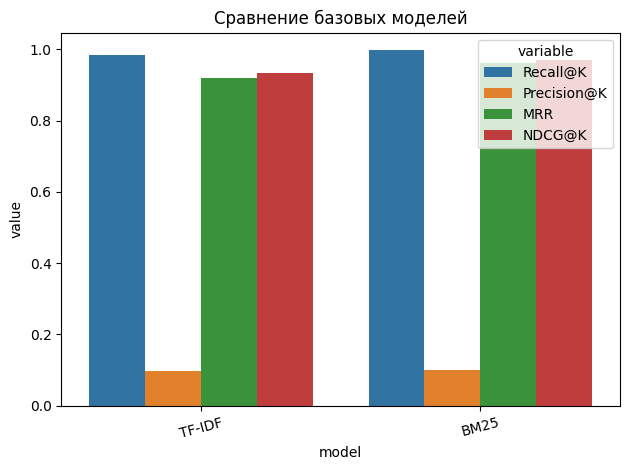

In [7]:
res_df = pd.DataFrame(results).T
res_df['model'] = res_df.index
sns.barplot(data=res_df.melt(id_vars='model', value_vars=['Recall@K', 'Precision@K', 'MRR', 'NDCG@K']), 
            x='model', y='value', hue='variable')
plt.title('Сравнение базовых моделей')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [8]:
with open('../artifacts/metrics.json', 'w') as f:
    json.dump(results, f, indent=2)